# Práctica 4 de integración

## Integración con `numerical_integral`
Dada una función $f$ y un intervalo $[a,b]$, el  comando `numerical_integral` devuelve la aproximación de la integral $\int_a^bf(x)\,\mathrm{d}x$ y la estimación del error cometido.

In [28]:
f = lambda x: 1/(1+x^2)
integr, error = numerical_integral(f, 0, 1)
integr, error

(0.7853981633974484, 8.719671245021581e-15)

Para obtener solo la aproximación de la integral, basta escoger el índice 0 de la salida.

In [44]:
numerical_integral(f, 0, 1)[0]

69.45462466669275

## La regla del trapecio compuesta

La regla del trapecio compuesta para $n$ subintervalos es:

$$\int_a^b f(x)\,\mathrm{d}x \approx h\left(\frac{f(a)}{2}+ \sum_{i=1}^{n-1}f(a+ih)+\frac{f(b)}{2}\right)$$

El error de esta regla converge a cero con orden cuadratico: $E_T = O(h^2) = O(\frac{1}{n^2}).$

Esta regla está programada en la siguiente función:

In [29]:
def trapecio(f, a, b, n):
    h = (b-a)/n
    return RDF(h*((f(a)+f(b))/2 + sum([f(x) for x in (a+h,a+2*h..b-h)])))

Usando esta función podemos calcular la aproximación de la integral:

In [30]:
f = lambda x: exp(-x^2)
trapecio(f, 0, 1, 4)

0.7429840978003812

Y comparar el error respecto del comando `numerical_integral`:

In [31]:
abs(numerical_integral(f, 0, 1)[0] - trapecio(f, 0, 1, 4000))

3.8320779882639044e-09

Queremos ver ahora que el error de trapecio es del tipo $O(\frac{1}{n^2})$. A tal fin, creamos la función `errot` que, dada una función matemática $f$, un intervalo de integración $[a, b]$ y un número de subdivisiones $n$, devuelve el error absoluto cometido pola regla del trapecio respecto de la integral calulada con `numerical_integral`.

In [32]:
errot = lambda f, a, b, n: abs(numerical_integral(f, a, b)[0] - trapecio(f, a, b, n))
errot(f, 0, 1, 4000)

3.8320779882639044e-09

Representamos la gráfica del error frente a $n\in\{10,20\ldots 100\}$ y comprobamos que el error tiende a cero.

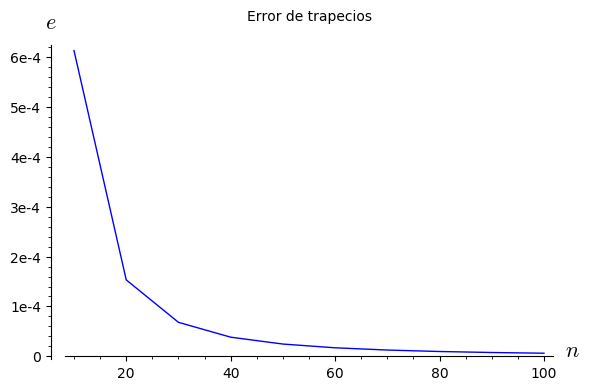

In [34]:
n = [10,20..100]
errot_n = lambda ni: errot(f, 0, 1, ni)
e = list(map(errot_n, n))
A = line(zip(n,e))
show(A, title='Error de trapecios', axes_labels=['$n$', '$e$'])

Como el observar a simple vista que el decaimiento del error para la fórmula del trapecio es $e = O(\frac{1}{n^2})$ es difícil, representamos a continuación la gráfica del error multiplicado por $n^2$ para comprobar que tiende a una constante positiva cuando $n$ crece.

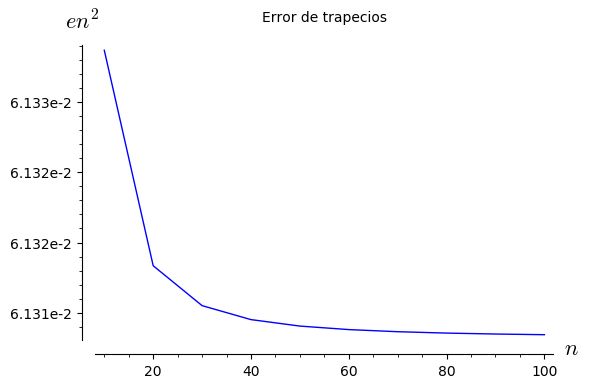

In [35]:
en2 = list(map(lambda i: e[i]*n[i]^2, range(len(n))))
A = line(zip(n, en2))
show(A, title='Error de trapecios', axes_labels=['$n$', '$e n^2$'])

## La regla de Simpson

La regla de Simpson compuesta para $n$ subintervalos, con $n$ par, es:

$$\int_a^b f(x)\,dx \approx \frac{h}{3}\left[
f(x_0) + 4f(x_1) + 2f(x_2) + \cdots + 2f(x_{n-2}) + 4f(x_{n-1}) + f(x_n)
\right]
$$

Observa quese deben multiplicar $f$ por cuatro en las abscisas $a+h,a+3h\ldots, b-h$ y por dos en $a+2h,a+4h\ldots, b-2h$.

El error de esta regla converge a cero con orden cuatro: $E_S = O(h^4) = O(\frac{1}{n^4}).$

**Ejercicio 1:**
1. Programa la regla de Simpson en la función `simpson(f,a,b,n)`. Comprueba en ella que $n$ no es impar (`is_even`) o menor que 2.
2. Aproxima con ella la integral de $\exp(-x^2)$ en $[0, 1]$ con 10 subdivisiones.

In [36]:
def simpson(f, a, b, n):
    if not is_even(n) or n<2:
        raise RuntimeError('n debe ser par >= 2.')
    h = (b-a)/n
    return (h*(f(a)+f(b)+4*sum([f(x) for x in (a+h,a+3*h..b-h)])+ \
                         2*sum([f(x) for x in (a+2*h,a+4*h..b-2*h)]))/3).n()

In [37]:
simpson(lambda x: exp(-x^2), 0, 1, 10)

0.746824948254443

**Ejercicio 2:**
1. Crea la función `erros` que, dada una función matemática $f$, un intervalo de integración $[a,b]$ y un número de subdivisiones $n$, devuelva el error absoluto cometido por la regla de Simpson respecto de `numerical_integral`. 
2. Representa la gráfica del valor del error frente a $n\in\{10,20\ldots 100\}$ y comprueba que el error tiende a cero.
3. Para comprobar que el error de Simpson es $O(\frac{1}{n^4})$, representa la gráfica del error multiplicado por $n^4$ y comprueba que tiende a una constante positiva cuando $n$ aumenta.

In [38]:
f = lambda x: exp(-x^2)
erros = lambda f, a, b, n: abs(numerical_integral(f, a, b)[0] - simpson(f, a, b, n))
erros(f, 0, 1, 10)

8.15442016466328e-7

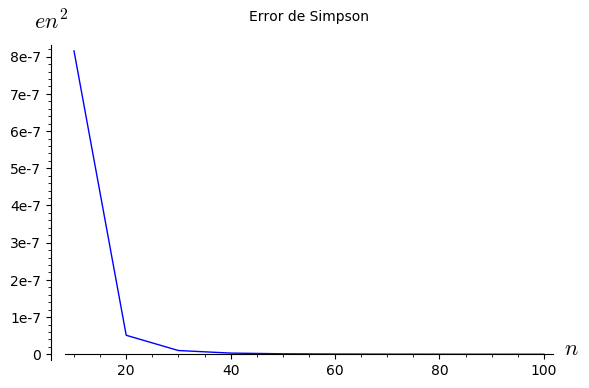

In [39]:
n = [10, 20 .. 100]
e = list(map(lambda ni: erros(f, 0, 1, ni), n))
A = line(zip(n,e))
show(A, title='Error de Simpson', axes_labels=['$n$', '$e n^2$'])

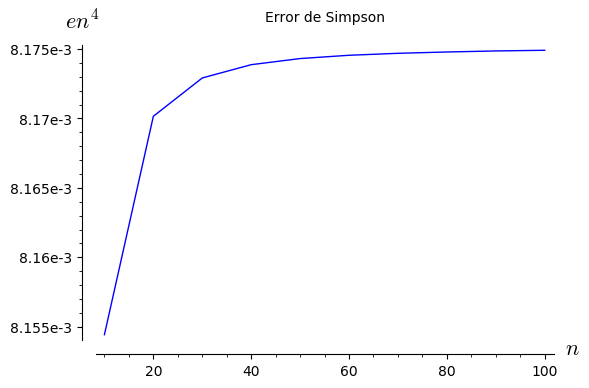

In [40]:
en4 = list(map(lambda i: e[i]*n[i]^4, range(len(n))))
A = line(zip(n, en4))
show(A, title='Error de Simpson', axes_labels=['$n$', '$e n^4$'])

**Ejercicio 3:**
1. Teniendo en cuenta que
    
$$\log(2) = \int_1^2 \frac{1}{x}\,\mathrm{d}x,$$
aproxima el valor de $\log(2)$ usando integración numérica, con la regla del trapecio y de Simpson con 40 subintervalos. ¿Cuál de las dos comete un error menor respecto de `numerical_integral`?

In [41]:
f = lambda x: 1/x
trapecio(f, 1, 2, 40), errot(f, 1, 2, 40)

(0.6931862400091405, 3.9059449195355533e-05)

In [42]:
simpson(f, 1, 2, 40), erros(f, 1, 2, 40)

(0.693147192747956, 1.21880108228112e-8)

**Ejercicio 4:**
1. Comprueba que la regla de Simpson integra de forma exacta cualquier polinomio de grado 3. Por ejemplo, $f(x) = x^3+x^2+x+1$.

In [43]:
erros(lambda x: x^3+x^2+x+1, 0, 1, 2)

0.000000000000000

## Idea

**Ejercicio adicional:** Regla de Gauss–Legendre compuesta de 3 puntos

**Regla de Gauss–Legendre de 3 puntos en $[-1,1]$**

La regla de Gauss–Legendre de 3 puntos en el intervalo $[-1,1]$ viene dada por

$\displaystyle
\int_{-1}^{1} f(t)\,dt \;\approx\; 
\sum_{i=1}^{3} w_i\, f(t_i),
$

donde los nodos son 

$\displaystyle \mathbf{t} = (-\sqrt{\frac{3}{5}},\ 0,\ \sqrt{\frac{3}{5}})$ 

y los pesos son 

$\displaystyle\mathbf{w} = (\frac{5}{9}, \ \frac{8}{9},\ \frac{5}{9}).$

**Cambio de variable a un intervalo general**

Para aplicar esta regla en un intervalo general $[x_0,x_1]$, se utiliza el cambio de variable

$\displaystyle x = c(x_0, x_1, t) = \frac{x_0+x_1}{2} + \frac{x_1-x_0}{2}\,t,$

con lo que

$\displaystyle
\int_{x_0}^{x_1} f(x)\,dx
= \frac{x_1-x_0}{2}\int_{-1}^{1} f\left(c(x_0,x_1,t)\right)\,dt.
$

Aplicando la regla de Gauss–Legendre de 3 puntos se obtiene la aproximación

$\displaystyle
\int_{x_0}^{x_1} f(x)\,dx
\;\approx\;
\frac{x_1-x_0}{2}\sum_{i=1}^{3}
w_i\, f\!\left(c(x_0,x_1,t_i)\right).
$

**Regla de Gauss–Legendre compuesta de 3 puntos**

Dividimos el intervalo $[a,b]$ en $n$ subintervalos de longitud $h=\frac{b-a}{n}$, dados por

$\displaystyle
[a,a+h],\;[a+h,a+2h],\;\ldots,\;[b-h,b].
$

Para cada subintervalo $[x_k,x_k+h]$ con

$\displaystyle
x_k = a + k\,h,\quad k=0,1,\ldots,n-1,
$

se aproxima la integral como

$\displaystyle
\int_{x_k}^{x_k+h} f(x)\,dx
\;\approx\;
\frac{h}{2}\sum_{i=1}^{3}
w_i\, f\!\left(c(x_k,x_k+h,t_i)\right).
$

La **regla de Gauss–Legendre compuesta de 3 puntos** queda definida como

$\displaystyle
G_n(f)
\;=\;
\sum_{k=0}^{n-1}
\frac{h}{2}\sum_{i=1}^{3}
w_i\, f\!\left(c(x_k,x_k+h,t_i)\right).
$

Si $f$ es suficientemente regular ($f\in C^6[a,b]$), el error global del método verifica

$\displaystyle
\left|\int_a^b f(x)\,dx - G_n(f)\right| = O\!\left(\frac{1}{n^6}\right).
$

**Trabajo a realizar**

1. Crea la función `erro` que, dada una función matemática $f$, un intervalo de integración $[a,b]$ y un número de subdivisiones $n$, devuelva el error absoluto cometido por la regla de Gauss–Legendre compuesta de 3 puntos respecto de `numerical_integral`.

2. Representa la gráfica del valor del error frente a  
$
n\in\{10,20,\ldots,100\}
$ 
y comprueba que el error tiende a cero cuando $n$ aumenta.

3. Para comprobar que el error de la regla de Gauss–Legendre compuesta de 3 puntos es  
$
O\!\left(\frac{1}{n^6}\right),
$ 
representa la gráfica del error multiplicado por $n^6$ y comprueba que dicha cantidad tiende a una constante positiva cuando $n$ aumenta.

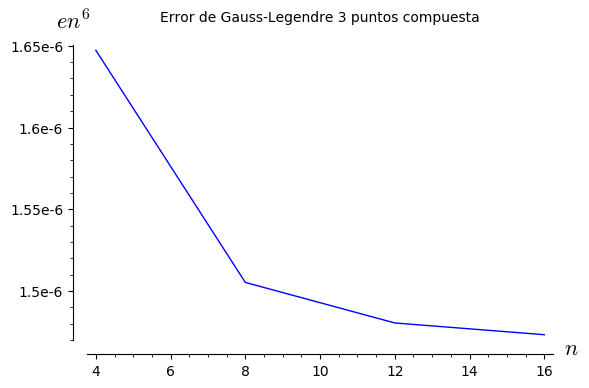

In [24]:
def gauss_legendre_3p_compuesta(f, a, b, n):
    c   = lambda a,b,t: (a+b)/2 + (b-a)*t/2
    w   = [5/9, 8/9, 5/9]
    t   = [-sqrt(15)/5, 0, sqrt(15)/5]
    h   = (b-a)/n
    res = 0
    for ai in [a, a+h .. b-h]:
        print
        res = res + RDF(h*sum([w[i]*f(c(ai, ai+h, t[i])) for i in range(len(t))])/2)
    return res
f = lambda x: exp(-x^2)
erro = lambda f, a, b, n: abs(RDF(integral(f(x),x,a,b)) - gauss_legendre_3p_compuesta(f, a, b, n))
n = [4, 8 .. 16]
e = list(map(lambda ni: erro(f, 0, 1, ni), n))
en6 = list(map(lambda i: e[i]*n[i]^6, range(len(n))))
A = line(zip(n, en6))
show(A, title='Error de Gauss-Legendre 3 puntos compuesta', axes_labels=['$n$', '$e n^6$'])